# AG-HYPOPT · Trial 09

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Eight trials recorded; best is trial 05 (0.0196), with trial 07 (0.0205) tied. Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294. The campaign has clearly converged: trials 05/06/07/08 all sit at lr_mu ~27 and sigma_ref ~6.2 and all hit the same mu floor (rel RMSE 15.3-15.6%), while gamma swings 12.6-18.5% run-to-run at the low-count Trans05 scans. So mu is a stable function of (lr_mu ~27, sigma_ref ~6.2) and cannot be pushed lower by these tunables, and the objective differences among plateau configs are within run-to-run noise (uncertainties ~0.008-0.013). lr_mu peaks near 27 (10 -> 0.098, 23 -> 0.048, 25 -> 0.025, 27 -> 0.020, 29 -> 0.026); sigma_ref is monotone (smaller better, saturated below ~6.3). We are in the TPE phase (9th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_09'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (8/5 trials)
ID |     ei | params
 1 | 3.9999 | {"gamma_anneal": 0.3899397501159928, "lr_gamma": 0.4189600161936162, "lr_mu": 27.05963708185149, "sigma_ref": 6.173642367808347}
 2 | 2.5372 | {"gamma_anneal": 0.32793600009713153, "lr_gamma": 0.42102800485160286, "lr_mu": 25.765535924281426, "sigma_ref": 6.175375425489017}
 3 | 0.4645 | {"gamma_anneal": 0.5290002784420903, "lr_gamma": 0.792598786300599, "lr_mu": 24.56477288320329, "sigma_ref": 6.308702035110724}
 4 | 3.9998 | {"gamma_anneal": 0.38018314357852245, "lr_gamma": 0.4090439291354445, "lr_mu": 27.027156733705702, "sigma_ref": 6.219267864169683}
 5 | 0.4804 | {"gamma_anneal": 0.40779731397502483, "lr_gamma": 0.24980279793333074, "lr_mu": 29.069539622929067, "sigma_ref": 9.521966547263428}
 6 | 3.9699 | {"gamma_anneal": 0.4324724767466633, "lr_gamma": 0.40941144533723456, "lr_mu": 27.07007253121439, "sigma_ref": 8.786640388564619}
 7 | 3.9937 | {"gamma_anneal": 0.400485371529134, "lr_gamma": 0.33551425044507144, "

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 05 (0.0196), trial 07 (0.0205) tied; trials 05-08 form a plateau at lr_mu ~27, sigma_ref ~6.2 with mu stuck at 15.3-15.6%. The TPE batch again clusters on that plateau: the top-ei draws #1 (3.9999), #4 (3.9998) and #7 (3.9937) all sit at lr_mu ~27, sigma_ref ~6.1-6.2, i.e. the same point as trials 05/07, and no candidate probes a genuinely new direction (the lower-ei #3/#5 raise lr_gamma or sigma_ref, already seen to hurt). Given the search has converged and rerunning the plateau only re-samples gamma noise, the most sensible choice remains the model's highest-ei draw, candidate 1 (lr_mu 27.06, sigma_ref 6.17, lr_gamma 0.419, gamma_anneal 0.390), to record one more measurement of the optimum; I do not expect a meaningful change from trial 05. I choose candidate 1.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.3899397501159928, 'lr_gamma': 0.4189600161936162, 'lr_mu': 27.05963708185149, 'sigma_ref': 6.173642367808347}
Running  1nW Trans05 ... 

μ 9.39 -> 6.90 | γ 8.5 -> 7.18 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 15.84 | γ 8.5 -> 7.95 | NLL 2.79


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 100.18 | γ 14.1 -> 13.82 | NLL 3.48


Running 3nW Trans100 ... 

μ 175.71 -> 164.54 | γ 14.1 -> 13.90 | NLL 2.79



Total: 7.0 min


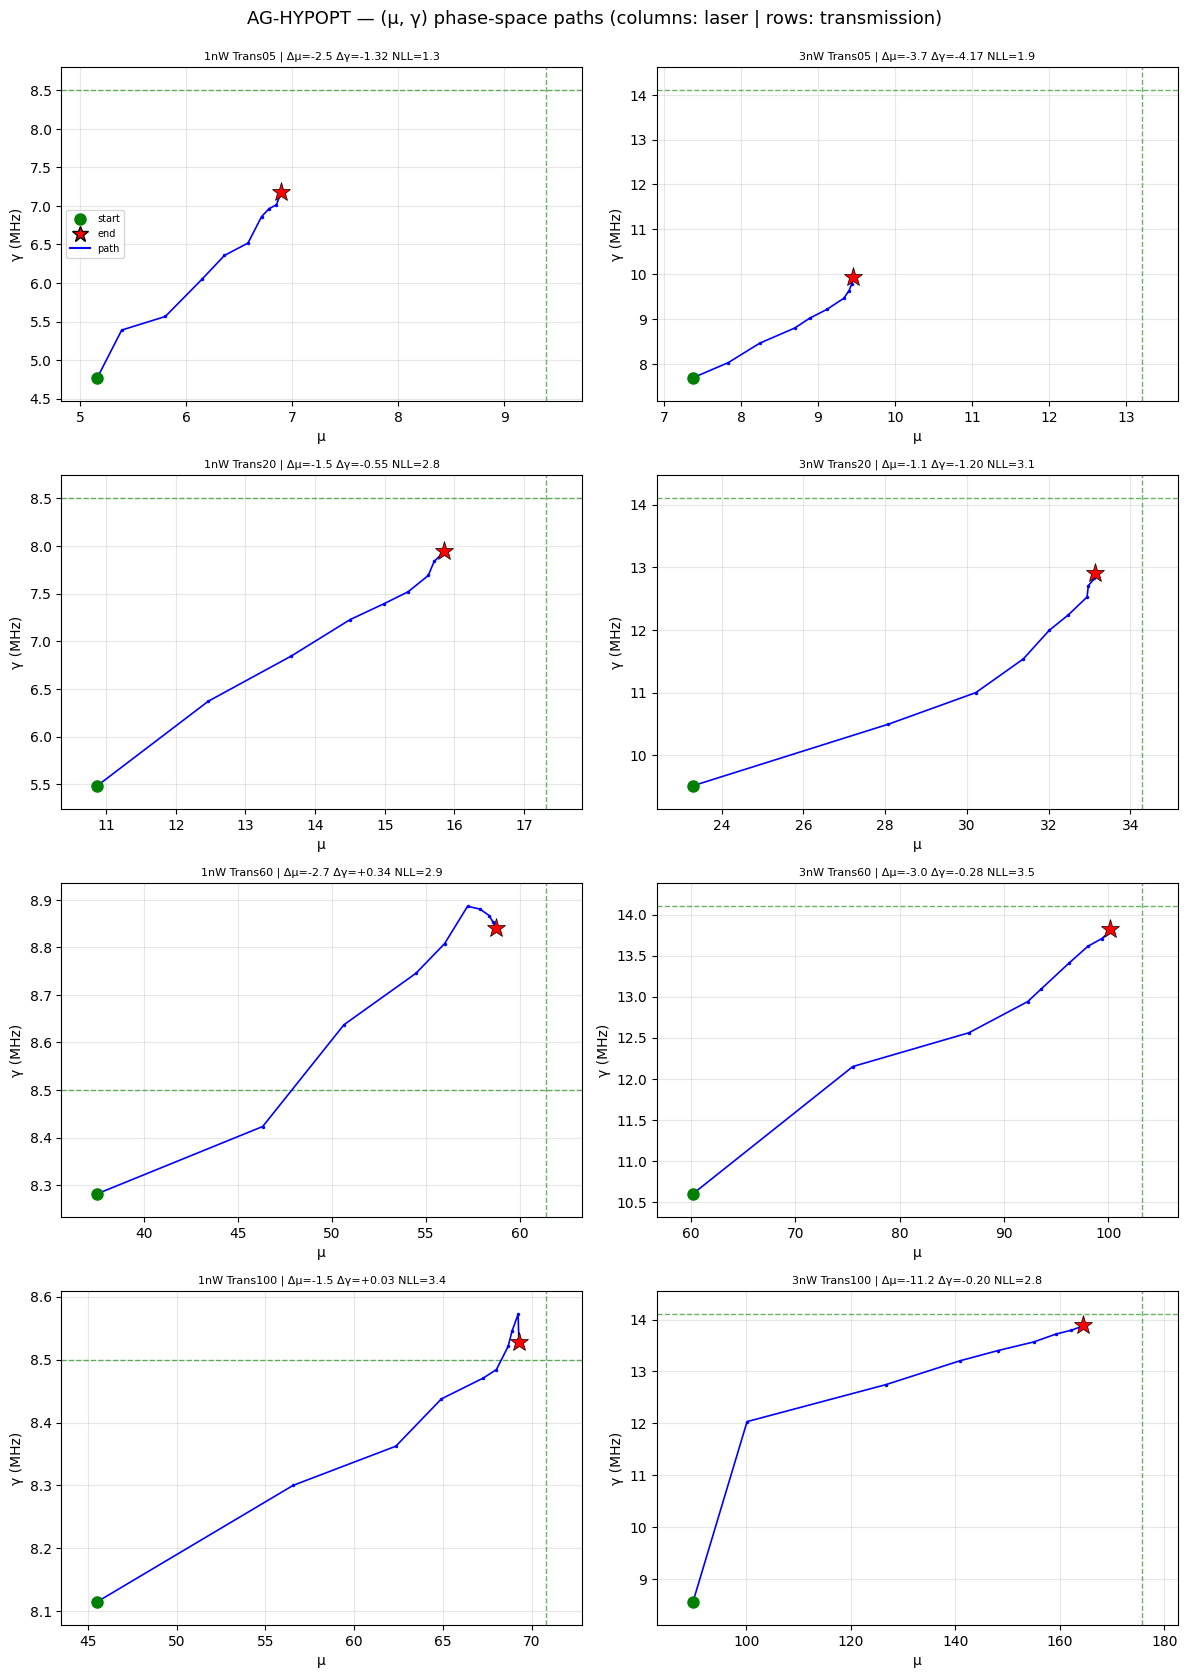

trial finished in 7.0 min
objective = 0.0182 ± 0.0078
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.90   -26.5 |     8.50    7.18   -15.5
1nW Trans20    17.32   15.84    -8.5 |     8.50    7.95    -6.5
1nW Trans60    61.37   58.69    -4.4 |     8.50    8.84    +4.0
1nW Trans100   70.82   69.29    -2.2 |     8.50    8.53    +0.3
3nW Trans05    13.20    9.46   -28.4 |    14.10    9.93   -29.6
3nW Trans20    34.28   33.14    -3.3 |    14.10   12.90    -8.5
3nW Trans60   103.20  100.18    -2.9 |    14.10   13.82    -2.0
3nW Trans100  175.71  164.54    -6.4 |    14.10   13.90    -1.4

μ: RMSE 4.571 (rel 14.4%, bias -3.408) | γ: RMSE 1.624 (rel 12.5%, bias -0.918)


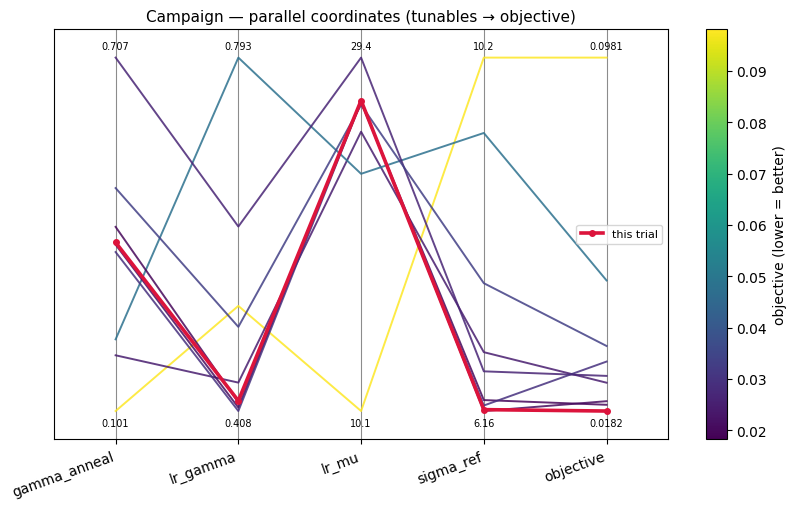

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 09 (sigma_ref 6.17, lr_mu 27.06, lr_gamma 0.419, gamma_anneal 0.390), the highest-ei TPE draw, ran 7.0 min and scored 0.0182 +/- 0.0078, the new best, edging past trial 05 (0.0196). It is the same plateau point as trials 05/07, but this run landed favourably: mu rel RMSE 14.4% (bias -3.4), just below the previous 15.3% floor, and gamma 12.5% (bias -0.9), the best gamma so far (1nW Trans05 gamma -15.5% and 3nW Trans05 -29.6% are both milder than in trial 08). The config is essentially trial 05's, so the objective spread across trials 05/07/08/09 (0.0196/0.0205/0.0294/0.0182) is dominated by the low-count Trans05 gamma, with trial 09 on the good side of that noise. mu is at its floor (14.4-15.6% across the plateau) and gamma is noise-limited; no tunable change has moved either materially.

**Summary:** Trial 09 (sigma_ref 6.17, lr_mu 27.06, lr_gamma 0.419, gamma_anneal 0.390), essentially the trial 05 point again, scored 0.0182 +/- 0.0078, the new best, with mu 14.4% and gamma 12.5% - both best-so-far, landing on the favourable side of the low-signal gamma noise.
**Key insight:** The plateau config (lr_mu ~27, sigma_ref ~6.2) gives mu 14.4-15.6%; trial 09's 0.0182 vs trial 08's 0.0294 at nearly the same point is driven by Trans05 gamma noise, so the true objective floor is about 0.018-0.020.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 09 (sigma_ref 6.17, lr_mu 27.06, lr_gamma 0.419, gamma_anneal 0.390), essentially the trial 05 point again, scored 0.0182 +/- 0.0078, the new best, with mu 14.4% and gamma 12.5% - both best-so-far, landing on the favourable side of the low-signal gamma noise.'
KEY_INSIGHT = 'The plateau config (lr_mu ~27, sigma_ref ~6.2) gives mu 14.4-15.6%; trial 09 0.0182 vs trial 08 0.0294 at nearly the same point is driven by Trans05 gamma noise, so the true objective floor is about 0.018-0.020.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_09 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_10.ipynb. Open it and follow its cells from the top.
